In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


df = pd.read_csv("cleaned_2.csv")

print("Dataset Loaded Successfully")
print(df.head())

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df = pd.get_dummies(df, drop_first=True)

TARGET_COLUMN = 'Status'

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

0 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 

Dataset Loaded Successfully
   Unnamed: 0 loan_limit             Gender approv_in_adv loan_type  \
0           0         cf  Sex Not Available         nopre     type1   
1           1         cf               Male         nopre     type2   
2           2         cf               Male           pre     type1   
3           3         cf               Male         nopre     type1   
4           4         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness business_or_commercial  loan_amount  \
0           p1                l1                  nob/c       116500   
1           p1                l1                    b/c       206500   
2           p1                l1                  nob/c       406500   
3           p4                l1                  nob/c       456500   
4           p1                l1                  nob/c       696500   

   rate_of_interest  ...  credit_type  Credit_Score        LTV Status dtir1  \
0              3.99  ...         

C:\Users\Tetra\AppData\Local\Temp\ipykernel_18652\4180023646.py:42: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Tetra\AppData\Local\Temp\ipykernel_18652\4180023646.py:42: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

In [15]:

models = {

    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=500
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=3
    ),

    "SVM": SVC(
        kernel='rbf',
        C=5,
        gamma=0.01
    )
}


results = []

for name, model in models.items():

    print("\n", "="*50)
    print(f"TRAINING: {name}")
    print("="*50)

    # Train Model
    model.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Save Results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # Print Metrics
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))



TRAINING: Logistic Regression
Accuracy  : 0.7914
Precision : 0.5732
Recall    : 0.6267
F1-Score  : 0.5987

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       227
           1       0.57      0.63      0.60        75

    accuracy                           0.79       302
   macro avg       0.72      0.74      0.73       302
weighted avg       0.80      0.79      0.79       302


TRAINING: KNN
Accuracy  : 0.8311
Precision : 0.7143
Recall    : 0.5333
F1-Score  : 0.6107

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       227
           1       0.71      0.53      0.61        75

    accuracy                           0.83       302
   macro avg       0.79      0.73      0.75       302
weighted avg       0.82      0.83      0.82       302


TRAINING: SVM
Accuracy  : 0.8543
Precision : 0.8605
Recall    : 0.4933
F1-Score  : 0.6271

Classi

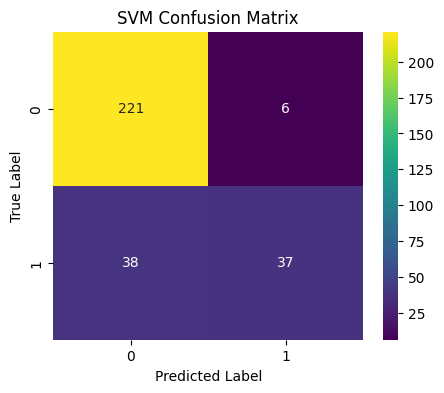

In [10]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='viridis'
)

plt.title(f'{name} Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.791391   0.573171  0.626667  0.598726
1                  KNN  0.831126   0.714286  0.533333  0.610687
2                  SVM  0.854305   0.860465  0.493333  0.627119


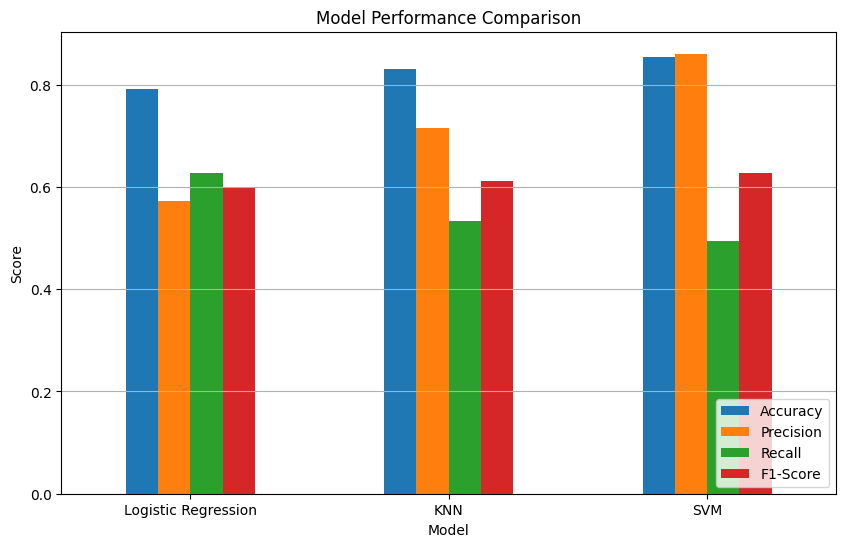

In [12]:

results_df = pd.DataFrame(results)

print("\nFINAL MODEL COMPARISON")
print(results_df)

results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y')

plt.show()


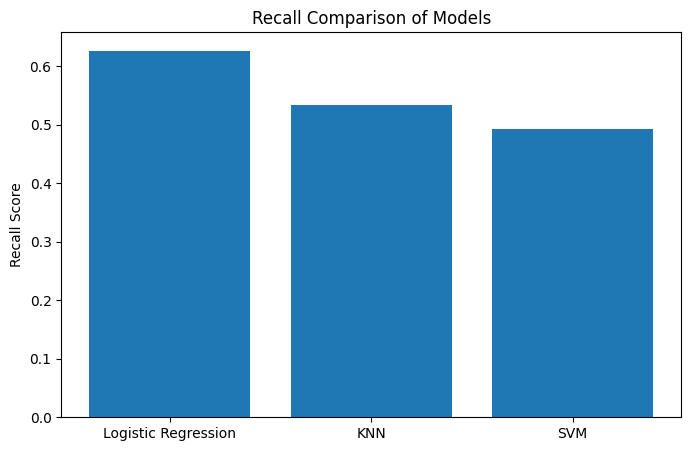

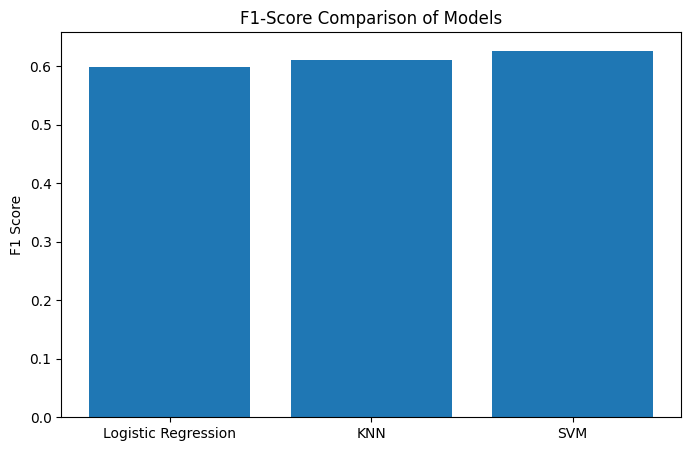

In [13]:

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['Recall']
)

plt.title('Recall Comparison of Models')
plt.ylabel('Recall Score')

plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['F1-Score']
)

plt.title('F1-Score Comparison of Models')
plt.ylabel('F1 Score')

plt.show()


In [14]:

best_model = results_df.sort_values(
    by='Recall',
    ascending=False
).iloc[0]

print("\nBEST MODEL BASED ON RECALL")
print(best_model)


BEST MODEL BASED ON RECALL
Model        Logistic Regression
Accuracy                0.791391
Precision               0.573171
Recall                  0.626667
F1-Score                0.598726
Name: 0, dtype: object
